# Práctica 6: Clasificación de los datos

Para esta sexta práctica, se ejecuta código para realizar modelo KNN entre los datos de tipo clasificatorios, haciendo uso del target.

## Librerías

Se importan las librerías necesarias.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo.

In [3]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Preparación de variables

Se mapea la variable de 'cardio', la cual es nuestro target.

In [4]:
df['cardio'] = df['cardio'].map({'Yes': 1, 'No': 0})

Obtener dummies de las variables categóricas.

In [5]:
df = pd.get_dummies(df, columns=[
    'gender',
    'cholesterol',
    'gluc',
    'smoke',
    'alco',
    'active'
], drop_first=True)

Se seleccionan las variables a utilizar.

In [6]:
X = df[
    [   'age',
        'height',
        'weight',
        'ap_hi',
        'ap_lo',
        'cholesterol_Normal',
        'cholesterol_Well Above Normal',
        'gluc_Normal',
        'gluc_Well Above Normal',
        'smoke_Yes',
        'alco_Yes',
        'active_Yes',
        'gender_Male'
    ]
]

y = df['cardio']

## Escalado de datos

Se utiliza el escalado estándar para las variables X.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Dividir el dataset

Se divide el dataset para tener un mejor manejo entre entrenamiento y pruebas.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Modelo

Se crea el modelo KNN.

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Evaluación del modelo

In [10]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6978641708663307


#### Mejora del modelo

Se busca obtener el mejor valor posible, probando con varios tipos diferentes de k.

In [11]:
scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

best_k = np.argmax(scores) + 1

print("Mejor k:", best_k)
print("Mejor accuracy:", max(scores))

Mejor k: 19
Mejor accuracy: 0.728421726261899


## Visualización del modelo

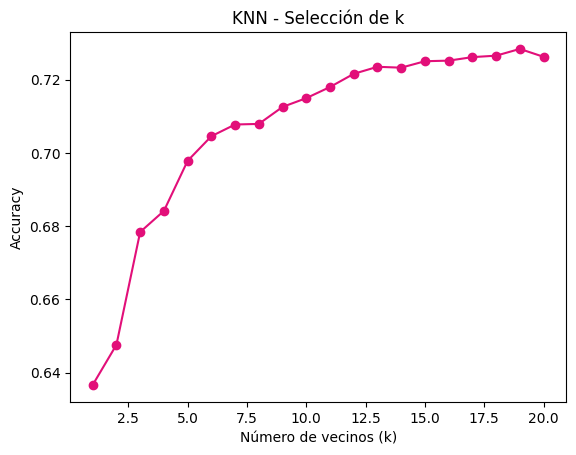

In [12]:
plt.plot(range(1,21), scores, color="#e20f79", marker='o')
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.title("KNN - Selección de k")

plt.show()